<a href="https://colab.research.google.com/github/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/blob/main/notebook/OLS_Regression_Analysis_of_NSE_Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OLS Regression Analysis of NSE Stocks

>**This section investigates what macroeconomic and sector-specific forces drive the excess return of Dangote Cement (DANGCEM), Nigeria's largest listed company by market capitalisation and the anchor of the NGX industrial sector. Using quarterly data from 2015 to 2025, the project applies Ordinary Least Squares (OLS) regression, Principal Component Analysis (PCA), and Monte Carlo simulation across four structured lessons.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot
import yfinance as yf
import requests
from io import StringIO
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
dang_url = "https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/DANGCEM%20Historical%20Data.csv"
dangcem = pd.read_csv(dang_url, parse_dates=True, index_col="Date")
dangcem.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,"1,180.00","1,180.00","1,180.00","1,180.00",950.64K,0.00%
29/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",843.91K,0.00%
28/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",437.82K,0.00%
26/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",437.82K,0.00%
25/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",1.38M,0.00%


In [3]:
gtco_url = "https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/GTCO%20Historical%20Data.csv"
gtco = pd.read_csv( gtco_url, parse_dates=True, index_col="Date")
gtco.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,136.00,137.00,137.0,135.85,27.67M,-0.73%
29/05/2026,137.00,140.00,141.5,137.00,21.66M,-2.14%
28/05/2026,140.00,144.35,140.0,140.00,13.12M,0.00%
26/05/2026,140.00,144.35,144.0,140.00,13.12M,-3.01%
25/05/2026,144.35,145.00,145.0,144.30,19.64M,-0.45%


In [4]:
usdngn_url = "https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/USD_NGN%20Historical%20Data.csv"
usdngn = pd.read_csv(usdngn_url, parse_dates=True, index_col="Date")
usdngn.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,"1,369.670","1,370.900","1,374.065","1,366.975",NaN,-0.16%
29/05/2026,"1,371.885","1,374.000","1,375.110","1,369.470",NaN,-0.14%
28/05/2026,"1,373.810","1,374.930","1,376.120","1,372.875",NaN,-0.03%
27/05/2026,"1,374.160","1,372.290","1,376.435","1,372.290",NaN,0.01%
26/05/2026,"1,374.020","1,371.330","1,375.845","1,370.550",NaN,0.20%


In [5]:
brent_url = "https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/Brent%20Oil%20Futures%20Historical%20Data.csv"
brent = pd.read_csv(brent_url, parse_dates=True, index_col="Date")
brent.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,94.98,92.58,97.79,92.20,373.98K,3.18%
29/05/2026,92.05,93.37,94.10,91.44,30.18K,-1.77%
28/05/2026,93.71,95.59,98.20,92.60,131.88K,-0.62%
27/05/2026,94.29,99.26,99.45,94.13,152.75K,-5.31%
26/05/2026,99.58,97.12,100.73,97.12,191.56K,3.58%


In [6]:
nse_url = "https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/NSE%20All%20Share%20Historical%20Data.csv"
nse = pd.read_csv(nse_url, parse_dates=True, index_col="Date")
nse.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,"247,571.13","250,385.47","250,597.31","247,527.73",1.13B,-1.12%
29/05/2026,"250,385.70","249,738.84","250,460.91","249,273.31",731.43M,0.26%
26/05/2026,"249,738.84","251,125.02","251,215.44","249,728.50",563.99M,-0.55%
25/05/2026,"251,125.02","249,712.38","251,170.59","249,093.11",629.26M,0.57%
22/05/2026,"249,712.38","249,175.39","249,854.11","249,175.39",711.83M,0.22%


In [7]:
def price_column_change(df):
  df = df.rename(columns={"Price": "Close"})
  # Only keep the 'Close' column and discard all others
  df = df[["Close"]]
  return df

In [8]:
dangcem = price_column_change(dangcem)
dangcem.head()

,Close
Date,
01/06/2026,"1,180.00"
29/05/2026,"1,180.00"
28/05/2026,"1,180.00"
26/05/2026,"1,180.00"
25/05/2026,"1,180.00"


In [9]:
dangcem.columns = ["dangcem_close"]
dangcem.head()

,dangcem_close
Date,
01/06/2026,"1,180.00"
29/05/2026,"1,180.00"
28/05/2026,"1,180.00"
26/05/2026,"1,180.00"
25/05/2026,"1,180.00"


In [10]:
gtco = price_column_change(gtco)
gtco.columns = ["gtco_close"]
gtco.head()

,gtco_close
Date,
01/06/2026,136.00
29/05/2026,137.00
28/05/2026,140.00
26/05/2026,140.00
25/05/2026,144.35


In [11]:
usdngn = price_column_change(usdngn)
usdngn.columns = ["usdngn_close"]
usdngn.head()

,usdngn_close
Date,
01/06/2026,"1,369.670"
29/05/2026,"1,371.885"
28/05/2026,"1,373.810"
27/05/2026,"1,374.160"
26/05/2026,"1,374.020"


In [12]:
brent = price_column_change(brent)
brent.columns = ["brent_close"]
brent.head()

,brent_close
Date,
01/06/2026,94.98
29/05/2026,92.05
28/05/2026,93.71
27/05/2026,94.29
26/05/2026,99.58


In [13]:
nse = price_column_change(nse)
nse.columns = ["nse_close"]
nse.head()

,nse_close
Date,
01/06/2026,"247,571.13"
29/05/2026,"250,385.70"
26/05/2026,"249,738.84"
25/05/2026,"251,125.02"
22/05/2026,"249,712.38"


In [14]:
df = pd.concat([dangcem, gtco, usdngn, brent, nse], axis=1)
df.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
01/06/2026,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
29/05/2026,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
28/05/2026,"1,180.00",140.00,"1,373.810",93.71,NaN
26/05/2026,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
25/05/2026,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [15]:
df.reset_index(inplace=True)
df.head()

,Date,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
0,01/06/2026,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
1,29/05/2026,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
2,28/05/2026,"1,180.00",140.00,"1,373.810",93.71,NaN
3,26/05/2026,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
4,25/05/2026,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [16]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df.head()

,Date,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
0,2026-06-01,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
1,2026-05-29,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
2,2026-05-28,"1,180.00",140.00,"1,373.810",93.71,NaN
3,2026-05-26,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
4,2026-05-25,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [17]:
df.set_index("Date", inplace=True)
df.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2026-06-01,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
2026-05-29,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
2026-05-28,"1,180.00",140.00,"1,373.810",93.71,NaN
2026-05-26,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
2026-05-25,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2871 entries, 2026-06-01 to 2015-07-17
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dangcem_close  2721 non-null   object 
 1   gtco_close     2718 non-null   float64
 2   usdngn_close   2871 non-null   object 
 3   brent_close    2841 non-null   float64
 4   nse_close      2721 non-null   object 
dtypes: float64(2), object(3)
memory usage: 134.6+ KB


In [19]:
for c in df.columns.to_list():
    if df[c].dtype == 'object':
        df[c] = df[c].str.replace(",", "")
    df[c] = pd.to_numeric(df[c], errors='coerce')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2871 entries, 2026-06-01 to 2015-07-17
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dangcem_close  2721 non-null   float64
 1   gtco_close     2718 non-null   float64
 2   usdngn_close   2871 non-null   float64
 3   brent_close    2841 non-null   float64
 4   nse_close      2721 non-null   float64
dtypes: float64(5)
memory usage: 134.6 KB


In [22]:
df.fillna(method="ffill", inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2871 entries, 2026-06-01 to 2015-07-17
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dangcem_close  2871 non-null   float64
 1   gtco_close     2871 non-null   float64
 2   usdngn_close   2871 non-null   float64
 3   brent_close    2871 non-null   float64
 4   nse_close      2871 non-null   float64
dtypes: float64(5)
memory usage: 134.6 KB


In [24]:
df.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2026-06-01,1180.0,136.00,1369.670,94.98,247571.13
2026-05-29,1180.0,137.00,1371.885,92.05,250385.70
2026-05-28,1180.0,140.00,1373.810,93.71,250385.70
2026-05-26,1180.0,140.00,1374.020,99.58,249738.84
2026-05-25,1180.0,144.35,1371.330,96.14,251125.02


In [25]:
df_quart = df.resample("QE").last()

In [ ]:
df_quart.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2015-06-30,180.00,27.01,198.98,63.59,33456.83
2015-09-30,179.99,24.00,198.98,48.37,31217.77
2015-12-31,170.00,18.18,199.00,37.28,28642.25
2016-03-31,167.80,14.30,198.80,39.60,25306.22
2016-06-30,192.00,23.26,281.72,49.68,29597.79


In [26]:
df_quart.tail()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2025-06-30,440.0,81.25,1536.375,67.61,119978.57
2025-09-30,525.1,93.90,1483.175,67.02,142710.45
2025-12-31,609.0,90.70,1444.570,60.85,155613.03
2026-03-31,810.0,112.65,1386.460,118.35,201287.78
2026-06-30,1180.0,136.00,1369.670,94.98,247571.13


In [28]:
t_bill_url = "https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/T_bill%20-%2091D.csv"
t_bill_91D = pd.read_csv(t_bill_url)
t_bill_91D.head()

,Date,91_Day_TBILL
0,Jun-15,9.95
1,Jul-15,10.00
2,Aug-15,10.00
3,Sep-15,10.36
4,Oct-15,9.11


In [29]:
t_bill_91D["Date"]= pd.to_datetime(t_bill_91D["Date"], format='%b-%y')
t_bill_91D.head()

,Date,91_Day_TBILL
0,2015-06-01,9.95
1,2015-07-01,10.00
2,2015-08-01,10.00
3,2015-09-01,10.36
4,2015-10-01,9.11


In [30]:
t_bill_91D.set_index("Date", inplace=True)
t_bill_91D.head()

,91_Day_TBILL
Date,
2015-06-01,9.95
2015-07-01,10.00
2015-08-01,10.00
2015-09-01,10.36
2015-10-01,9.11


In [31]:
t_bill_91D.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 127 entries, 2015-06-01 to 2025-12-01
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   91_Day_TBILL  127 non-null    object
dtypes: object(1)
memory usage: 2.0+ KB


In [35]:
t_bill_91D['91_Day_TBILL'] = pd.to_numeric(t_bill_91D['91_Day_TBILL'], errors='coerce')
t_bill_91D['91_Day_TBILL'] = (1 + t_bill_91D['91_Day_TBILL']/100)**(1/4) - 1
t_bill_91D.head()

,91_Day_TBILL
Date,
2015-06-01,0.023997
2015-07-01,0.024114
2015-08-01,0.024114
2015-09-01,0.024951
2015-10-01,0.022036


In [36]:
t_bill_91D_quart = t_bill_91D.resample("QE").last()
t_bill_91D_quart.head()

,91_Day_TBILL
Date,
2015-06-30,0.023997
2015-09-30,0.024951
2015-12-31,0.011234
2016-03-31,0.013547
2016-06-30,0.020181


In [37]:
t_bill_91D_quart.tail()

,91_Day_TBILL
Date,
2024-12-31,0.042247
2025-03-31,0.040941
2025-06-30,0.042026
2025-09-30,0.035941
2025-12-31,0.036412


In [38]:
for col in ['dangcem_close', 'usdngn_close', 'nse_close']:
    df_quart[col] = pd.to_numeric(df_quart[col], errors='coerce')
returns = df_quart.loc["2015-06-30":"2025-12-31"].pct_change().dropna()

In [39]:
excess_return = pd.DataFrame()

In [41]:
excess_return['dangcem_excess'] = returns['dangcem_close'] - t_bill_91D_quart['91_Day_TBILL']
excess_return['gtco_excess'] = returns['gtco_close'] - t_bill_91D_quart['91_Day_TBILL']
excess_return["usdngn_excess"] = returns["usdngn_close"]
excess_return["brent_excess"] = returns["brent_close"]
excess_return["nse_excess"] = returns["nse_close"] - t_bill_91D_quart["91_Day_TBILL"]

In [42]:
excess_return.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess
Date,,,,,
2015-06-30,NaN,NaN,NaN,NaN,NaN
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.091874
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.093736
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.130020
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.149405


In [43]:
excess_return.dropna(inplace=True)

In [44]:
excess_return.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess
Date,,,,,
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.091874
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.093736
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.130020
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.149405
2016-09-30,-0.080174,-0.001485,0.080860,-0.012480,-0.075951


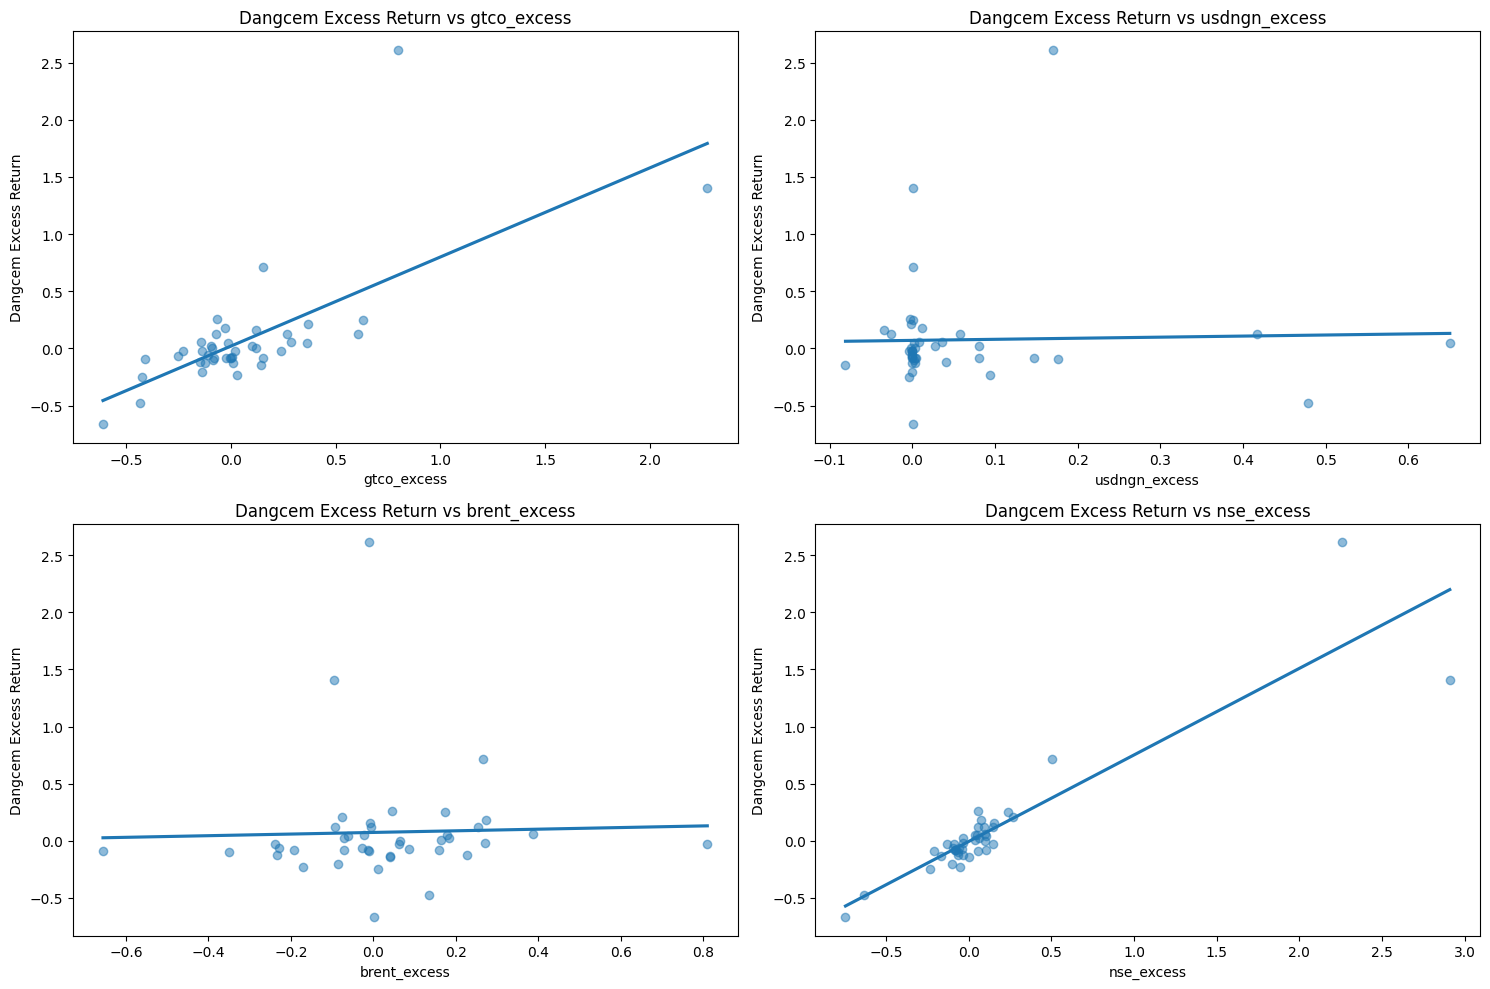

In [45]:
x_variables = ["gtco_excess", "usdngn_excess", "brent_excess", "nse_excess"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes =axes.flatten()

for i, var in enumerate(x_variables):
    sns.regplot(x=var, y='dangcem_excess', data=excess_return, ax=axes[i], scatter_kws={'alpha': 0.5}, ci=None)
    axes[i].set_title(f'Dangcem Excess Return vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Dangcem Excess Return')

plt.tight_layout()
plt.savefig("Regressions_Plots_variables.png", dpi=300)
plt.show()

In [46]:
corr = excess_return.corr()
print("Correlations with DANGCEM excess return:")
print(corr["dangcem_excess"].sort_values(ascending=False).drop("dangcem_excess"))

Correlations with DANGCEM excess return:
nse_excess       0.906614
gtco_excess      0.692300
brent_excess     0.032371
usdngn_excess    0.026487
Name: dangcem_excess, dtype: float64


In [47]:
def correlation(x, y , **kwargs):
  coef = np.corrcoef(x, y)[0][1]
  label = r"$\rho$ = " + str(round(coef, 2))
  ax = plt.gca()
  ax.annotate(label, xy=(0.2, 0.95), size=16,
              xycoords=ax.transAxes)

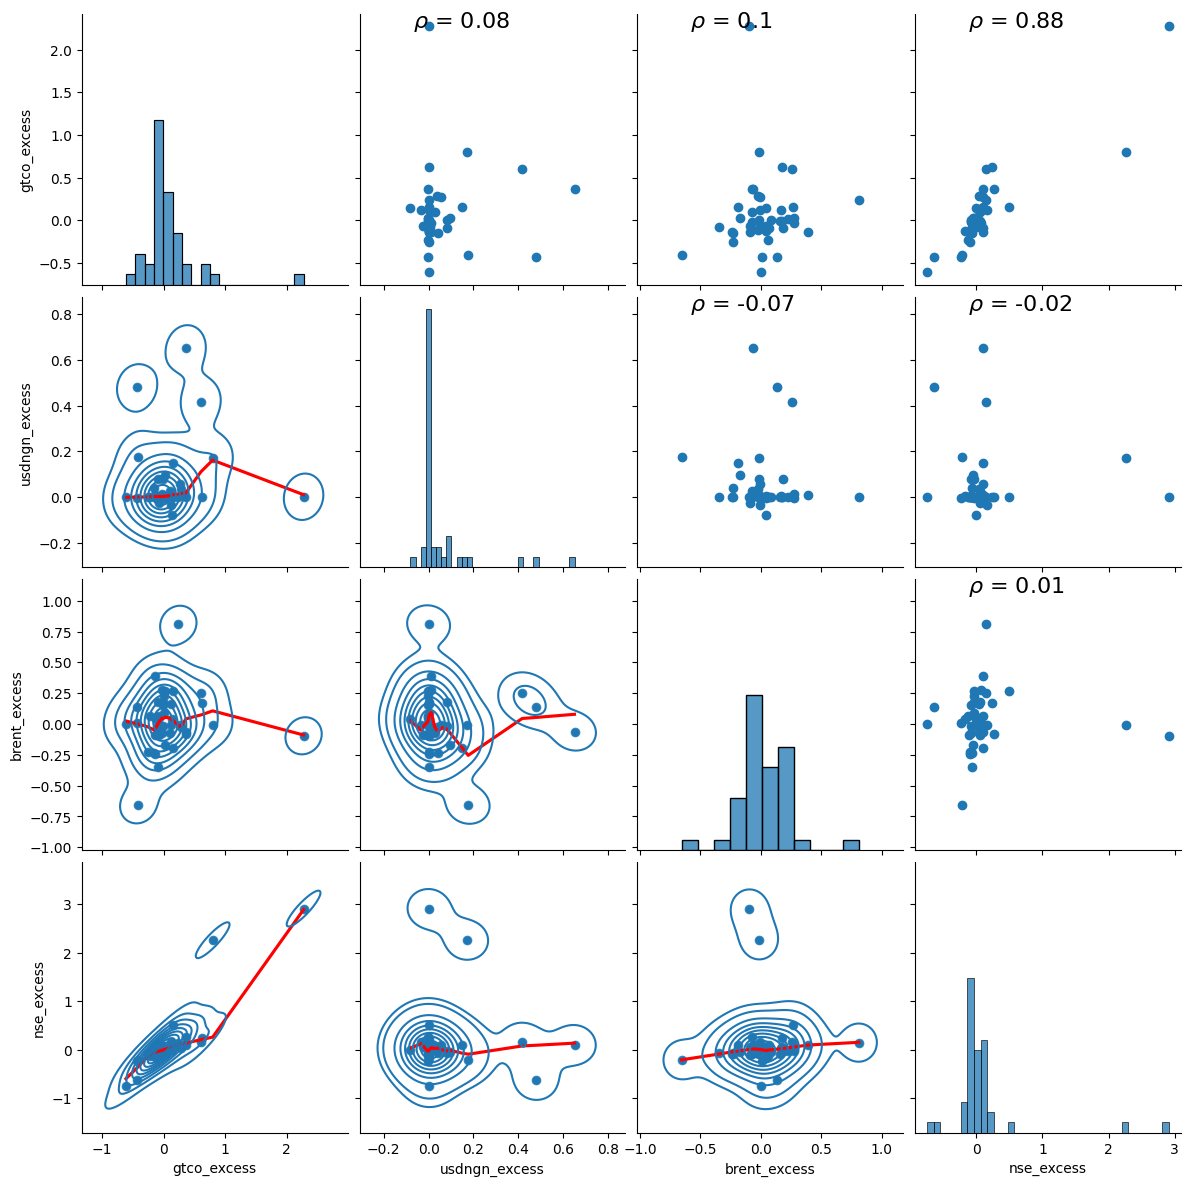

In [48]:
grid = sns.pairplot(excess_return, vars=x_variables, height=3)

grid = grid.map_upper(plt.scatter)
grid = grid.map_upper(correlation)
grid = grid.map_lower(sns.regplot, lowess=True, line_kws = {"color": "red"})
grid = grid.map_lower(sns.kdeplot)

In [49]:
result = smf.ols('dangcem_excess ~ gtco_excess + usdngn_excess + brent_excess + nse_excess', data=excess_return).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     76.25
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.37e-17
Time:                        21:58:34   Log-Likelihood:                 16.627
No. Observations:                  42   AIC:                            -23.25
Df Residuals:                      37   BIC:                            -14.57
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.0317      0.030     -1.066

In [50]:
result.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,-0.031670,0.029698,-1.066387,2.931581e-01,-0.091844,0.028504
gtco_excess,-0.649682,0.135858,-4.782061,2.760475e-05,-0.924957,-0.374407
usdngn_excess,0.385844,0.197940,1.949295,5.887120e-02,-0.015221,0.786910
brent_excess,0.191758,0.122125,1.570176,1.248877e-01,-0.055691,0.439207
nse_excess,1.183998,0.099942,11.846836,3.726425e-14,0.981496,1.386500


In [51]:
X = sm.add_constant(excess_return[x_variables], prepend=True)
y = excess_return["dangcem_excess"]
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     76.25
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.37e-17
Time:                        22:01:12   Log-Likelihood:                 16.627
No. Observations:                  42   AIC:                            -23.25
Df Residuals:                      37   BIC:                            -14.57
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0317      0.030     -1.066

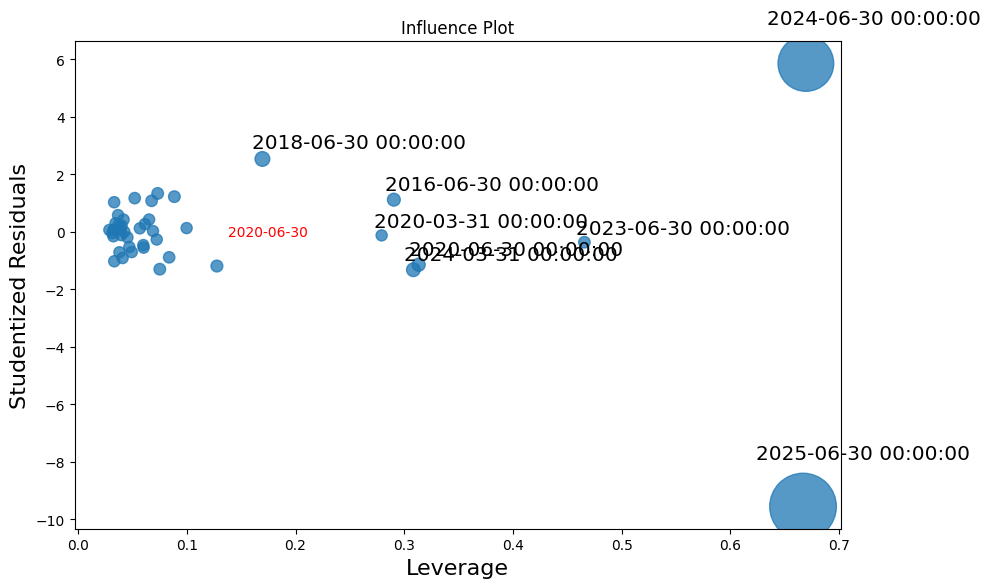

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
influence_plot(results, ax=ax, criterion="cooks")
ax.set_title("Influence Plot")
influence = results.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(y)
outlier_idx = np.where(cooks_d > threshold)[0]
for idx in outlier_idx:
    ax.annotate(str(excess_return.index[idx].date()),
                xy=(results.fittedvalues.iloc[idx],
                    results.resid.iloc[idx]),
                fontsize=10, color="red")

plt.tight_layout()
plt.savefig("influence_plot.png", dpi=300)
plt.show()

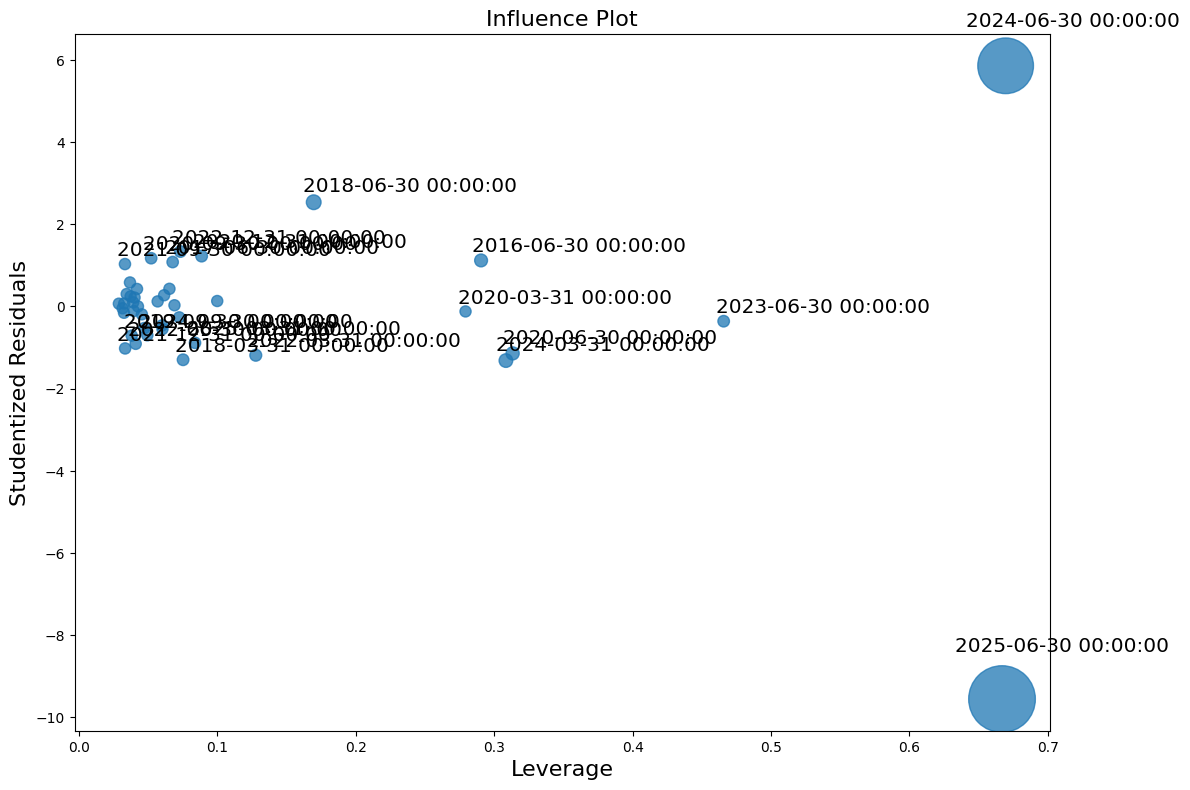

In [53]:
fig = sm.graphics.influence_plot(result, criterion="cooks", alpha=0.5)
plt.tight_layout(pad=1.0)
plt.savefig("influence_plot_1.png", dpi=300)
plt.show()

In [54]:
influence = results.get_influence()
inf_sum = influence.summary_frame().sort_values("cooks_d", ascending=False)
inf_sum.head(10)

,dfb_const,dfb_gtco_excess,dfb_usdngn_excess,dfb_brent_excess,dfb_nse_excess,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
Date,,,,,,,,,,,
2025-06-30,-1.370241,-5.257603,2.025446,2.593521,-0.758857,10.626287,-5.151072,0.666936,-7.289131,-9.553205,-13.518460
2024-06-30,-0.598108,-5.698907,2.662050,1.018271,7.671972,7.313417,4.248271,0.669544,6.047072,5.855093,8.334254
2018-06-30,0.504884,1.008408,-0.376957,0.049586,-0.859283,0.228868,2.367512,0.169545,1.069737,2.535210,1.145510
2024-03-31,0.044233,0.224679,-0.777641,-0.212708,-0.069274,0.151836,-1.304697,0.308432,-0.871309,-1.317611,-0.879933
2020-06-30,-0.126811,-0.014844,0.038422,-0.716641,0.009344,0.118190,-1.138113,0.313293,-0.768731,-1.142810,-0.771904
2016-06-30,-0.005369,0.357600,0.451121,0.161567,-0.307712,0.101868,1.115377,0.290487,0.713682,1.119177,0.716113
2022-03-31,-0.134238,0.258366,-0.014417,-0.359311,-0.227540,0.040870,-1.181546,0.127687,-0.452052,-1.188099,-0.454559
2020-12-31,0.136823,-0.203911,-0.014184,0.243359,0.240146,0.028736,1.216101,0.088549,0.379049,1.224272,0.381596
2022-12-31,0.246586,0.301732,-0.101611,-0.112662,-0.281094,0.027596,1.321751,0.073198,0.371455,1.335682,0.375370


In [55]:
zenith_url ="https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/ZENITHB%20Historical%20Data.csv"
zenithb = pd.read_csv(zenith_url, parse_dates=True, index_col="Date")
zenithb.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,128.85,131.10,131.5,128.10,32.94M,-1.72%
29/05/2026,131.10,132.00,135.0,129.50,23.97M,-0.68%
26/05/2026,132.00,131.95,132.5,131.80,33.83M,0.04%
25/05/2026,131.95,132.00,132.0,131.25,37.93M,-0.04%
22/05/2026,132.00,132.00,132.0,130.55,24.39M,0.00%


In [56]:
access_url = "https://raw.githubusercontent.com/Sahdam/NIGERIA-NSE-STOCK-PROJECT-PLAN/refs/heads/main/datasets/ACCESSCORP%20Historical%20Data.csv"
access = pd.read_csv(access_url, parse_dates=True, index_col="Date")
access.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,24.00,24.00,24.85,24.0,130.26M,-0.21%
29/05/2026,24.05,24.60,24.70,24.0,133.28M,-2.24%
26/05/2026,24.60,25.00,24.90,24.2,80.61M,-1.60%
25/05/2026,25.00,24.95,25.00,24.5,61.29M,0.20%
22/05/2026,24.95,25.00,25.30,24.6,69.67M,-1.38%


In [57]:
zenithb = price_column_change(zenithb)
zenithb.columns = ["zenithb_close"]
zenithb.head()

,zenithb_close
Date,
01/06/2026,128.85
29/05/2026,131.10
26/05/2026,132.00
25/05/2026,131.95
22/05/2026,132.00


In [58]:
access = price_column_change(access)
access.columns = ["access_close"]
access.head()

,access_close
Date,
01/06/2026,24.00
29/05/2026,24.05
26/05/2026,24.60
25/05/2026,25.00
22/05/2026,24.95


In [59]:
df2 = pd.concat([zenithb, access], axis=1)
df2.head()

,zenithb_close,access_close
Date,,
01/06/2026,128.85,24.00
29/05/2026,131.10,24.05
26/05/2026,132.00,24.60
25/05/2026,131.95,25.00
22/05/2026,132.00,24.95


In [61]:
df2.reset_index(inplace=True)
df2.head()

,Date,zenithb_close,access_close
0,01/06/2026,128.85,24.00
1,29/05/2026,131.10,24.05
2,26/05/2026,132.00,24.60
3,25/05/2026,131.95,25.00
4,22/05/2026,132.00,24.95


In [62]:
df2["Date"] = pd.to_datetime(df2["Date"], dayfirst=True)
df2.head()

,Date,zenithb_close,access_close
0,2026-06-01,128.85,24.00
1,2026-05-29,131.10,24.05
2,2026-05-26,132.00,24.60
3,2026-05-25,131.95,25.00
4,2026-05-22,132.00,24.95


In [63]:
df2.set_index("Date", inplace=True)
df2.head()

,zenithb_close,access_close
Date,,
2026-06-01,128.85,24.00
2026-05-29,131.10,24.05
2026-05-26,132.00,24.60
2026-05-25,131.95,25.00
2026-05-22,132.00,24.95


In [64]:
df2_quart = df2.resample("QE").last()

In [65]:
df2_quart.head()

,zenithb_close,access_close
Date,,
2015-06-30,19.25,NaN
2015-09-30,16.81,NaN
2015-12-31,14.05,NaN
2016-03-31,10.75,NaN
2016-06-30,15.77,NaN


In [66]:
df2_quart.isnull().sum()

,0
zenithb_close,0
access_close,27


In [67]:
df2_quart.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45 entries, 2015-06-30 to 2026-06-30
Freq: QE-DEC
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   zenithb_close  45 non-null     float64
 1   access_close   18 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


In [79]:
df2_quart.fillna(method="bfill", inplace=True)

In [80]:
df2_quart.isnull().sum()

,0
zenithb_close,0
access_close,0


In [81]:
return_1 = df2_quart.pct_change().dropna()

In [82]:
return_1.head()

,zenithb_close,access_close
Date,,
2015-09-30,-0.126753,0.0
2015-12-31,-0.164188,0.0
2016-03-31,-0.234875,0.0
2016-06-30,0.466977,0.0
2016-09-30,-0.035510,0.0


In [85]:
return_1.tail()

,zenithb_close,access_close
Date,,
2025-06-30,0.211702,-0.011186
2025-09-30,0.211589,0.160633
2025-12-31,-0.104348,-0.181287
2026-03-31,0.550162,0.230952
2026-06-30,0.344990,-0.071567


In [86]:
excess_return["zenithb_excess"] = return_1["zenithb_close"] - t_bill_91D_quart["91_Day_TBILL"]
excess_return["access_excess"] = return_1["access_close"] - t_bill_91D_quart["91_Day_TBILL"]

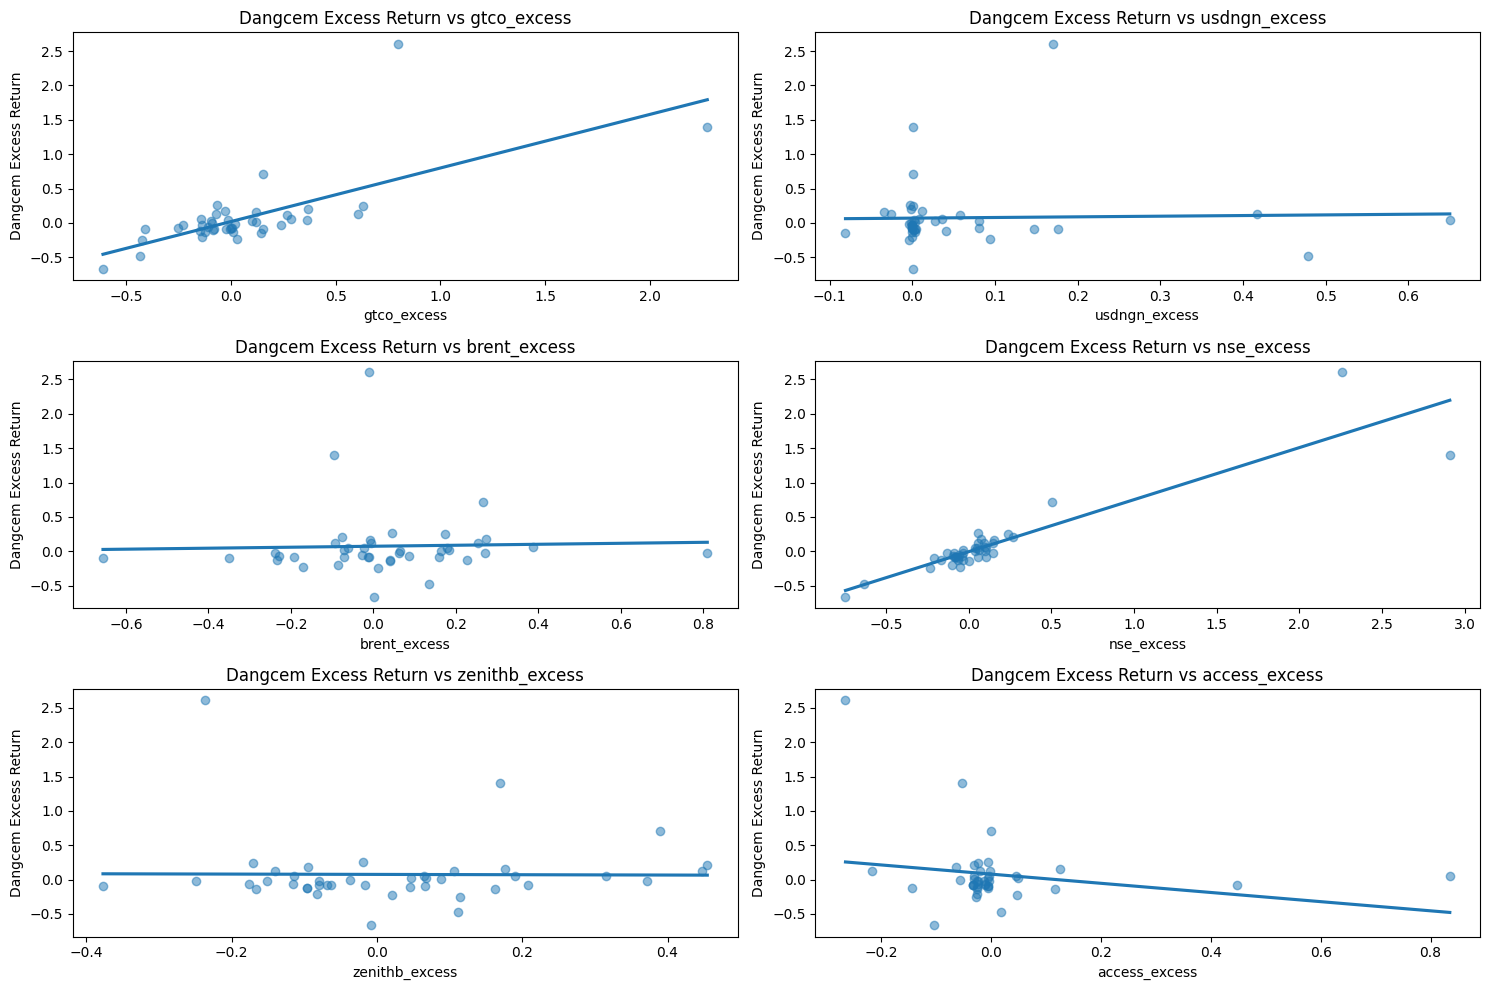

In [87]:
x_variables_extra = ["gtco_excess", "usdngn_excess", "brent_excess", "nse_excess","zenithb_excess", "access_excess"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axes =axes.flatten()

for i, var in enumerate(x_variables_extra):
    sns.regplot(x=var, y='dangcem_excess', data=excess_return, ax=axes[i], scatter_kws={'alpha': 0.5}, ci=None)
    axes[i].set_title(f'Dangcem Excess Return vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Dangcem Excess Return')

plt.tight_layout()
plt.savefig("Regressions_Plots_variables_extra.png", dpi=300)
plt.show()

In [88]:
excess_return.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 42 entries, 2015-09-30 to 2025-12-31
Freq: QE-DEC
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dangcem_excess  42 non-null     float64
 1   gtco_excess     42 non-null     float64
 2   usdngn_excess   42 non-null     float64
 3   brent_excess    42 non-null     float64
 4   nse_excess      42 non-null     float64
 5   zenithb_excess  42 non-null     float64
 6   access_excess   42 non-null     float64
dtypes: float64(7)
memory usage: 2.6 KB


In [89]:
corr_2 = excess_return.corr()
print("Correlations with DANGCEM excess return + extra variable:")
print(corr_2["dangcem_excess"].sort_values(ascending=False).drop("dangcem_excess"))

Correlations with DANGCEM excess return + extra variable:
nse_excess        0.906614
gtco_excess       0.692300
brent_excess      0.032371
usdngn_excess     0.026487
zenithb_excess   -0.008814
access_excess    -0.218513
Name: dangcem_excess, dtype: float64


In [77]:
excess_return_2 = excess_return

In [90]:
excess_return_2.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess,zenithb_excess,access_excess
Date,,,,,,,
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.091874,-0.151704,-0.024951
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.093736,-0.175422,-0.011234
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.130020,-0.248423,-0.013547
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.149405,0.446796,-0.020181
2016-09-30,-0.080174,-0.001485,0.080860,-0.012480,-0.075951,-0.068810,-0.033299


In [91]:
excess_return_2.dropna(inplace=True)
excess_return_2.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess,zenithb_excess,access_excess
Date,,,,,,,
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.091874,-0.151704,-0.024951
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.093736,-0.175422,-0.011234
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.130020,-0.248423,-0.013547
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.149405,0.446796,-0.020181
2016-09-30,-0.080174,-0.001485,0.080860,-0.012480,-0.075951,-0.068810,-0.033299


In [92]:
excess_return_2.replace([np.inf, -np.inf], np.nan, inplace=True)
excess_return_2.dropna(inplace=True)
model_2 = smf.ols('dangcem_excess ~ gtco_excess + usdngn_excess + brent_excess + nse_excess + zenithb_excess + access_excess', data=excess_return_2).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     49.71
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.09e-15
Time:                        22:09:29   Log-Likelihood:                 17.247
No. Observations:                  42   AIC:                            -20.49
Df Residuals:                      35   BIC:                            -8.330
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0361      0.030     -1.

In [93]:
model_2.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,-0.036062,0.030407,-1.185967,2.436245e-01,-0.097792,0.025668
gtco_excess,-0.594522,0.159445,-3.728690,6.789938e-04,-0.918212,-0.270831
usdngn_excess,0.515691,0.237665,2.169820,3.689431e-02,0.033205,0.998177
brent_excess,0.176973,0.133691,1.323748,1.941683e-01,-0.094434,0.448380
nse_excess,1.140332,0.114065,9.997248,8.539420e-12,0.908768,1.371895
zenithb_excess,-0.009024,0.192273,-0.046934,9.628322e-01,-0.399360,0.381311
access_excess,-0.221666,0.227095,-0.976096,3.357153e-01,-0.682693,0.239360


In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [95]:
labels = [
    "Intercept", "gtco_excess", "usdngn_excess", "brent_excess", "nse_excess", "zenithb_excess", "access_excess"
]

In [96]:
variables = model_2.model.exog
vif = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
vif_data = pd.DataFrame({"Variable": labels, "VIF": vif})
vif_data

,Variable,VIF
0,Intercept,1.256551
1,gtco_excess,6.686070
2,usdngn_excess,1.489111
3,brent_excess,1.228897
4,nse_excess,6.219852
5,zenithb_excess,1.763340
6,access_excess,1.842513


In [97]:
high_vif = vif_data[vif_data["VIF"] > 5]["Variable"].to_list()
print(high_vif)

['gtco_excess', 'nse_excess']


In [98]:
excess_return_3 = excess_return.drop(columns=['zenithb_excess', 'access_excess'])

In [99]:
excess_return_3.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess
Date,,,,,
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.091874
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.093736
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.130020
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.149405
2016-09-30,-0.080174,-0.001485,0.080860,-0.012480,-0.075951


In [100]:
X_new = excess_return_3.drop(columns=["dangcem_excess"])

In [113]:
X_new.head()

,gtco_excess,usdngn_excess,brent_excess,nse_excess
Date,,,,
2015-09-30,-0.136391,0.000000,-0.239346,-0.091874
2015-12-31,-0.253734,0.000101,-0.229274,-0.093736
2016-03-31,-0.226969,-0.001005,0.062232,-0.130020
2016-06-30,0.606393,0.417103,0.254545,0.149405
2016-09-30,-0.001485,0.080860,-0.012480,-0.075951


In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [102]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

In [103]:
pca = PCA()
pca.fit(X_scaled)

PCA()

In [104]:
explained = pca.explained_variance_ratio_
cummulative = np.cumsum(explained)

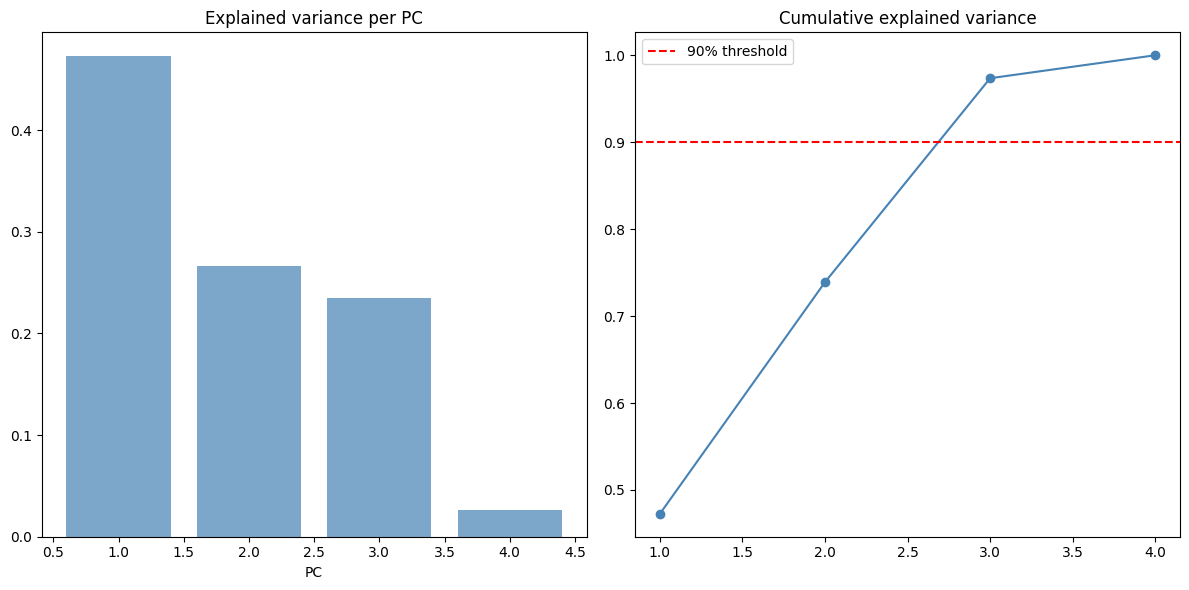

PCs needed for 90% variance: 3


In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].bar(range(1, len(explained)+1), explained, color="steelblue", alpha=0.7)
axes[0].set_title("Explained variance per PC"); axes[0].set_xlabel("PC")
axes[1].plot(range(1, len(cummulative)+1), cummulative, "o-", color="steelblue")
axes[1].axhline(0.9, color="red", linestyle="--", label="90% threshold")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()
plt.tight_layout()
plt.savefig("pca_scree.png", dpi=150)
plt.show()

n_90 = np.argmax(cummulative >= 0.9) + 1
print(f"PCs needed for 90% variance: {n_90}")

In [114]:
pca.components_

array([[ 0.70751591,  0.04116962,  0.07785353,  0.70118837],
       [ 0.02259706,  0.72111798, -0.69234429,  0.01173082],
       [ 0.0218267 ,  0.68627552,  0.71311194, -0.14149511],
       [ 0.70599873, -0.08555602, -0.07790743, -0.69869621]])

PCA Loadings:
                 PC1    PC2    PC3    PC4
gtco_excess    0.708  0.023  0.022  0.706
usdngn_excess  0.041  0.721  0.686 -0.086
brent_excess   0.078 -0.692  0.713 -0.078
nse_excess     0.701  0.012 -0.141 -0.699

Highest loading in PC1: gtco_excess


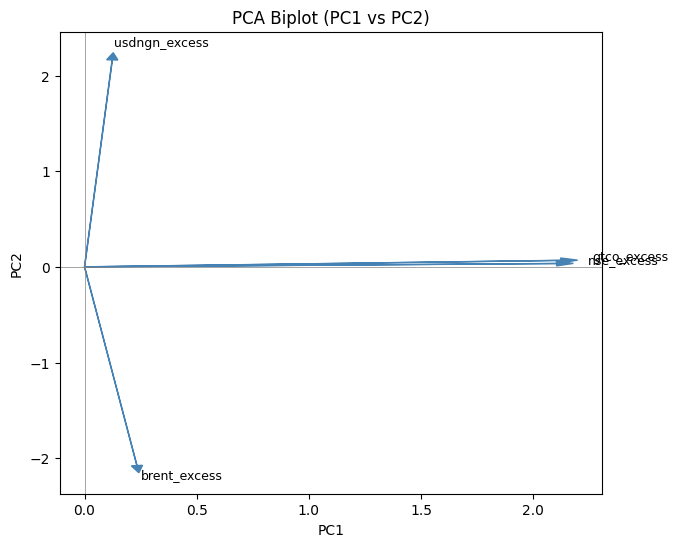

In [106]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_new.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("PCA Loadings:")
print(loadings.round(3))

# PC1 dominant variable
pc1_dominant = loadings["PC1"].abs().idxmax()
print(f"\nHighest loading in PC1: {pc1_dominant}")

# Biplot (optional but informative)
plt.figure(figsize=(7, 6))
for i, var in enumerate(X_new.columns):
    plt.arrow(0, 0, pca.components_[0,i]*3,
              pca.components_[1,i]*3,
              head_width=0.05, color="steelblue")
    plt.text(pca.components_[0,i]*3.2,
             pca.components_[1,i]*3.2, var, fontsize=9)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA Biplot (PC1 vs PC2)")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.savefig("pca_biplot.png", dpi=150)
plt.show()

In [107]:
# Option A: PCR (Principal Components Regression)
X_pca = pca.transform(X_scaled)[:, :n_90]
pc_cols = [f"PC{i+1}" for i in range(n_90)]
X_pcr = sm.add_constant(
    pd.DataFrame(X_pca, index=excess_return_3.index, columns=pc_cols)
)
model_pcr = sm.OLS(excess_return_3["dangcem_excess"], X_pcr).fit()
print("PCR Summary:")
print(model_pcr.summary())

# Option B: PCA-informed variable selection
# Keep variables with |loading| > 0.3 in PC1
keep_vars = loadings[loadings["PC1"].abs() > 0.3].index.tolist()
print(f"\nVariables kept by PCA guidance: {keep_vars}")
X_guided = sm.add_constant(excess_return_3[keep_vars])
model_guided = sm.OLS(excess_return_3["dangcem_excess"], X_guided).fit()
print(model_guided.summary())

PCR Summary:
                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     26.97
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.62e-09
Time:                        22:13:56   Log-Likelihood:                -6.1215
No. Observations:                  42   AIC:                             20.24
Df Residuals:                      38   BIC:                             27.19
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0753      0.045      1

In [108]:
from scipy import stats

brent = excess_return_3["brent_excess"].copy()

# Shift to positive for Box-Cox
shift = abs(brent.min()) + 1
brent_shifted = brent + shift
brent_bc, lambda_bc = stats.boxcox(brent_shifted)

print(f"Optimal lambda: {lambda_bc:.4f}")
# lambda ≈ 1 → no transformation needed
# lambda ≈ 0 → log transform appropriate
# lambda ≈ 0.5 → square root

# Compare normality: Shapiro-Wilk
sw_orig = stats.shapiro(brent)
sw_bc   = stats.shapiro(brent_bc)
print(f"Shapiro-Wilk (original): stat={sw_orig.statistic:.4f}, p={sw_orig.pvalue:.4f}")
print(f"Shapiro-Wilk (Box-Cox):  stat={sw_bc.statistic:.4f},  p={sw_bc.pvalue:.4f}")

# Re-run OLS with transformed Brent
excess_return_3["BRENT_BC"] = brent_bc
X_bc = sm.add_constant(excess_return_3[['gtco_excess', 'usdngn_excess',
       'nse_excess', "BRENT_BC"]])
model_bc = sm.OLS(excess_return_3["dangcem_excess"], X_bc).fit()
print(f"\nAIC before: {results.aic:.2f} → after Box-Cox: {model_bc.aic:.2f}")

Optimal lambda: 0.7852
Shapiro-Wilk (original): stat=0.9313, p=0.0144
Shapiro-Wilk (Box-Cox):  stat=0.9331,  p=0.0165

AIC before: -23.25 → after Box-Cox: -23.35


In [109]:
fitted_ret = results.fittedvalues + t_bill_91D_quart['91_Day_TBILL'].reindex(results.fittedvalues.index)
mean = fitted_ret.mean()
std = results.resid.std()

month_mean = (1 + mean) ** (1/3) -1
month_std = std / np.sqrt(3)

print (f"Quarterly mean return: {mean:.4f}({mean * 100:.2f}%)")
print (f"Quarterly std: {std:.4f}({std * 100:.2f}%)")
print (f"Monthly mean return: {month_mean:.4f}({month_mean * 100:.2f}%)")
print (f"Monthly std: {month_std:.4f}({month_std * 100:.2f}%)")

Quarterly mean return: 0.0967(9.67%)
Quarterly std: 0.1648(16.48%)
Monthly mean return: 0.0313(3.13%)
Monthly std: 0.0952(9.52%)


In [110]:
np.random.seed(42)
simulation = 10_000
month = 12
monthly_invest = 10_000

monthly_ret = np.random.normal(month_mean, month_std, size=(simulation, month))

portfolio = np.zeros((simulation, month + 1))

for i in range(1, month + 1):
  portfolio[:, i] = ((portfolio[:, i-1] + monthly_invest) * (1 + monthly_ret[:, i-1]))
final_val = portfolio[:, i]

print(f" Expected final value(mean): {final_val.mean():.2f}")
print(f" Expected final percentile(95th): {np.percentile(final_val, 95):.2f}")
print(f" Expected final percentile(5th): {np.percentile(final_val, 5):.2f}")
print(f" Probability of loss: {(final_val < 120_000).mean()*100:.2f}%")

 Expected final value(mean): 147723.14
 Expected final percentile(95th): 203916.57
 Expected final percentile(5th): 103005.31
 Probability of loss: 18.27%


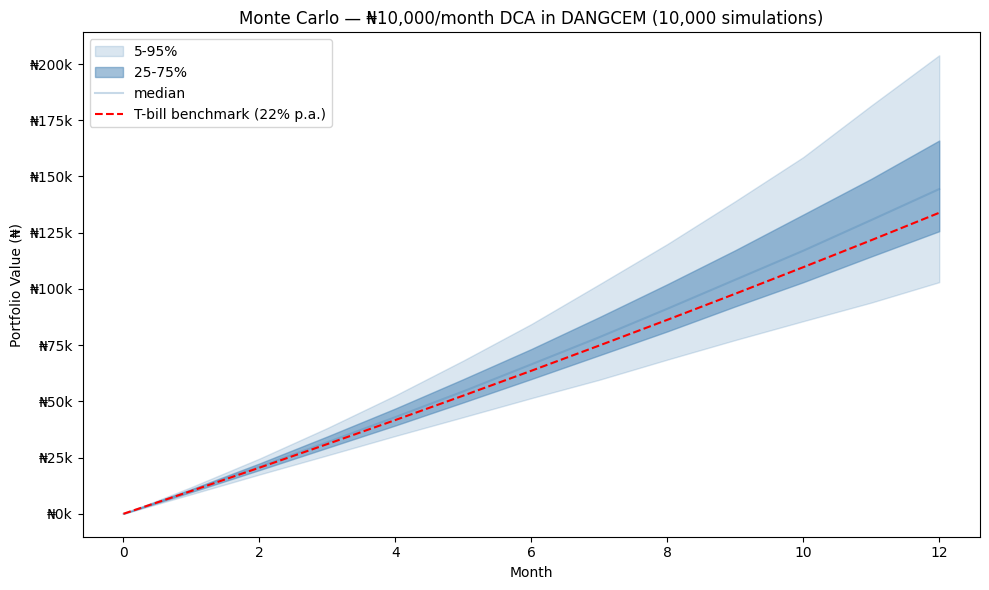

In [111]:
months = np.arange(0, month + 1)

pct_5 = np.percentile(portfolio, 5, axis=0)
pct_25 = np.percentile(portfolio, 25, axis=0)
pct_50 = np.percentile(portfolio, 50, axis=0)
pct_75 = np.percentile(portfolio, 75, axis=0)
pct_95 = np.percentile(portfolio, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(months, pct_5, pct_95, color="steelblue", alpha=0.2, label = "5-95%")
ax.fill_between(months, pct_25, pct_75, color="steelblue", alpha=0.5, label = "25-75%")
ax.plot(months, pct_50, color ="steelblue", alpha=0.3, label="median")

# T-bill deterministic benchmark
tbill_rate_m = (1 + 0.22) ** (1/12) - 1
tbill_path = np.array(
    [monthly_invest * ((1+tbill_rate_m)**k - 1) / tbill_rate_m * (1+tbill_rate_m)
     for k in range(month +1)]
)
ax.plot(months, tbill_path, "r--", linewidth=1.5, label="T-bill benchmark (22% p.a.)")

ax.set_xlabel("Month"); ax.set_ylabel("Portfolio Value (₦)")
ax.set_title("Monte Carlo — ₦10,000/month DCA in DANGCEM (10,000 simulations)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"₦{x/1000:.0f}k"))
ax.legend(); plt.tight_layout()
plt.savefig("montecarlo_fan.png", dpi=150)

In [112]:
tbill_final = tbill_path[-1]

comparison = pd.DataFrame({
    "Scenario": ["T-bill (deterministic)", "DANGCEM 5th pct (worst case)",
                 "DANGCEM median", "DANGCEM 95th pct (best case)"],
    "Final Portfolio (₦)": [
        tbill_final,
        np.percentile(final_val, 5),
        np.percentile(final_val, 50),
        np.percentile(final_val, 95)
    ]
})
comparison["Total Invested"]  = 120_000
comparison["Return (₦)"]      = comparison["Final Portfolio (₦)"] - 120_000
comparison["Return (%)"]      = (comparison["Return (₦)"] / 120_000 * 100).round(1)
comparison["Final Portfolio (₦)"] = comparison["Final Portfolio (₦)"].round(0)

print(comparison.to_string(index=False))
comparison.to_csv("comparison.csv", index=False)

                    Scenario  Final Portfolio (₦)  Total Invested    Return (₦)  Return (%)
      T-bill (deterministic)             133866.0          120000  13865.854131        11.6
DANGCEM 5th pct (worst case)             103005.0          120000 -16994.685565       -14.2
              DANGCEM median             144406.0          120000  24405.960176        20.3
DANGCEM 95th pct (best case)             203917.0          120000  83916.573691        69.9


# Advanced Regression — FX and Nigerian Macro Factors

>Project Question
How do global and domestic factors explain the USD/NGN exchange rate daily return? And which regression method is most appropriate?
